# NOTE: my google colab ended with all 3 ids, last one is did not ran completely

## Text-to-Image Generation using GANs

## Class Activity 7 - Deep Learning Fall 2025

**Models**: GAN-CLS, StackGAN-v2, AttnGAN | **Datasets**: CUB-200-2011

**Muhammad Umer**: F2023266912
**Talal Zahid**: F2022266500


In [1]:
!pip install -q torch torchvision ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q pytorch-fid scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os, torch, torch.nn as nn, torch.optim as optim, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import clip
from scipy import linalg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

Device: cuda


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 214MiB/s]


In [3]:
# Configuration - 300 epochs, full dataset
class Config:
    noise_dim = 100
    text_dim = 512
    ca_dim = 128
    ngf = 64
    ndf = 64
    batch_size = 32
    lr = 0.0002
    epochs = 300  # Increased for better quality
    data_dir = "./data"


cfg = Config()
os.makedirs(cfg.data_dir, exist_ok=True)
print(f"Training for {cfg.epochs} epochs")

Training for 300 epochs


## 1. Dataset Download & Preparation


In [4]:
import urllib.request, tarfile

CUB_URL = "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz"
CUB_PATH = os.path.join(cfg.data_dir, "CUB_200_2011.tgz")

if not os.path.exists(os.path.join(cfg.data_dir, "CUB_200_2011")):
    print("Downloading CUB-200-2011...")
    urllib.request.urlretrieve(CUB_URL, CUB_PATH)
    with tarfile.open(CUB_PATH, "r:gz") as tar:
        tar.extractall(cfg.data_dir)
    print("Done!")
else:
    print("CUB-200-2011 already exists")

/tmp/ipython-input-2842268151.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(cfg.data_dir)


Done!


In [5]:
# Dataset - ALL 200 classes, ALL images
class BirdDataset(Dataset):
    def __init__(self, root, img_size=64):
        self.transform = transforms.Compose(
            [
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize([0.5] * 3, [0.5] * 3),
            ]
        )
        self.images, self.captions = [], []
        img_dir = os.path.join(root, "CUB_200_2011", "images")
        if os.path.exists(img_dir):
            for cls in os.listdir(img_dir):  # ALL classes
                cls_path = os.path.join(img_dir, cls)
                if os.path.isdir(cls_path):
                    for img in os.listdir(cls_path):  # ALL images
                        if img.endswith(".jpg"):
                            self.images.append(os.path.join(cls_path, img))
                            self.captions.append(
                                f"a photo of a {cls.split('.')[1].replace('_', ' ')} bird"
                            )
        print(f"Loaded {len(self.images)} images")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return (
            self.transform(Image.open(self.images[idx]).convert("RGB")),
            self.captions[idx],
        )


dataset = BirdDataset(cfg.data_dir)
dataloader = DataLoader(
    dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True, num_workers=2
)

Loaded 11788 images


## 2. GAN Models


In [6]:
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)


class ConditioningAugmentation(nn.Module):
    def __init__(self, text_dim, ca_dim):
        super().__init__()
        self.fc = nn.Linear(text_dim, ca_dim * 2)
        self.ca_dim = ca_dim

    def forward(self, x):
        x = self.fc(x)
        mu, logvar = x[:, : self.ca_dim], x[:, self.ca_dim :]
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar), mu, logvar

In [7]:
# GAN-CLS
class GAN_CLS_G(nn.Module):
    def __init__(self, noise_dim=100, text_dim=512, ngf=64):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(noise_dim + text_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise, text):
        return self.main(torch.cat([noise, text], 1).unsqueeze(-1).unsqueeze(-1))


class GAN_CLS_D(nn.Module):
    def __init__(self, text_dim=512, ndf=64):
        super().__init__()
        self.img_enc = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, True),
        )
        self.text_proj = nn.Linear(text_dim, ndf * 8)
        self.classifier = nn.Conv2d(ndf * 16, 1, 4, 1, 0)

    def forward(self, img, text):
        h = self.img_enc(img)
        t = self.text_proj(text).view(-1, h.size(1), 1, 1).expand(-1, -1, 4, 4)
        return torch.sigmoid(self.classifier(torch.cat([h, t], 1))).view(-1)

In [8]:
# StackGAN-v2
class StackGAN_G(nn.Module):
    def __init__(self, noise_dim=100, text_dim=512, ca_dim=128, ngf=64):
        super().__init__()
        self.ca = ConditioningAugmentation(text_dim, ca_dim)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(noise_dim + ca_dim, ngf * 8, 4, 1, 0),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, noise, text):
        c, mu, logvar = self.ca(text)
        return (
            self.main(torch.cat([noise, c], 1).unsqueeze(-1).unsqueeze(-1)),
            mu,
            logvar,
        )


class StackGAN_D(GAN_CLS_D):
    pass

In [9]:
# AttnGAN
class AttnGAN_G(nn.Module):
    def __init__(self, noise_dim=100, text_dim=512, ca_dim=128, ngf=64):
        super().__init__()
        self.ca = ConditioningAugmentation(text_dim, ca_dim)
        self.init = nn.Sequential(
            nn.ConvTranspose2d(noise_dim + ca_dim, ngf * 8, 4, 1, 0),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
        )
        self.out = nn.Sequential(nn.ConvTranspose2d(ngf, 3, 4, 2, 1), nn.Tanh())

    def forward(self, noise, text, words=None):
        c, mu, logvar = self.ca(text)
        return (
            self.out(self.init(torch.cat([noise, c], 1).unsqueeze(-1).unsqueeze(-1))),
            mu,
            logvar,
        )


class AttnGAN_D(GAN_CLS_D):
    pass

## 3. Training


In [10]:
def get_text_emb(caps):
    with torch.no_grad():
        emb = clip_model.encode_text(
            clip.tokenize(caps, truncate=True).to(device)
        ).float()
    return emb / emb.norm(dim=-1, keepdim=True)


def train_epoch(G, D, loader, g_opt, d_opt, use_ca=False):
    G.train()
    D.train()
    criterion = nn.BCELoss()
    g_losses, d_losses = [], []
    for imgs, caps in tqdm(loader, leave=False):
        bs = imgs.size(0)
        imgs, text = imgs.to(device), get_text_emb(caps)
        real_lbl, fake_lbl = (
            torch.ones(bs, device=device) * 0.9,
            torch.zeros(bs, device=device) + 0.1,
        )
        # D
        d_opt.zero_grad()
        noise = torch.randn(bs, cfg.noise_dim, device=device)
        out = G(noise, text)
        fake = out[0] if isinstance(out, tuple) else out
        d_loss = criterion(D(imgs, text), real_lbl) + criterion(
            D(fake.detach(), text), fake_lbl
        )
        d_loss.backward()
        d_opt.step()
        # G
        g_opt.zero_grad()
        out = G(noise, text)
        fake = out[0] if isinstance(out, tuple) else out
        g_loss = criterion(D(fake, text), torch.ones(bs, device=device))
        if use_ca and isinstance(out, tuple):
            g_loss += 0.001 * (
                -0.5 * torch.mean(1 + out[2] - out[1].pow(2) - out[2].exp())
            )
        g_loss.backward()
        g_opt.step()
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())
    return np.mean(g_losses), np.mean(d_losses)


def visualize(G, caps, n=4):
    G.eval()
    with torch.no_grad():
        out = G(torch.randn(n, cfg.noise_dim, device=device), get_text_emb(caps[:n]))
        imgs = ((out[0] if isinstance(out, tuple) else out).cpu() + 1) / 2
    fig, ax = plt.subplots(1, n, figsize=(n * 3, 3))
    for i in range(n):
        ax[i].imshow(imgs[i].permute(1, 2, 0).clamp(0, 1).numpy())
        ax[i].set_title(caps[i][:25] + "...")
        ax[i].axis("off")
    plt.tight_layout()
    plt.show()


test_caps = [
    "a photo of a blue bird",
    "a photo of a red cardinal",
    "a photo of a yellow warbler",
    "a photo of a black crow",
]

## 4. Train All Models (300 epochs)


Training GAN-CLS...


Epoch 50: G=2.4393 D=0.8050


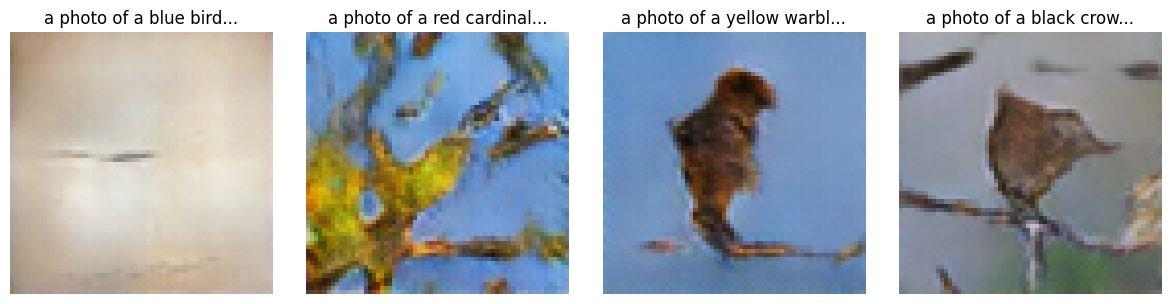

Epoch 100: G=2.4547 D=0.7535


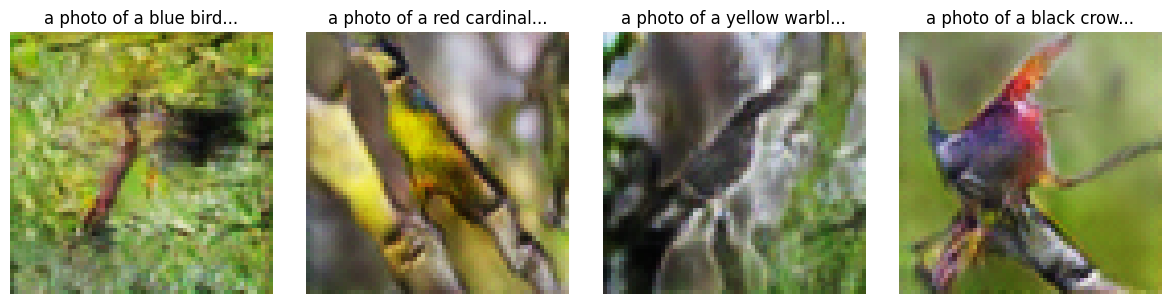

Epoch 150: G=2.4375 D=0.7333


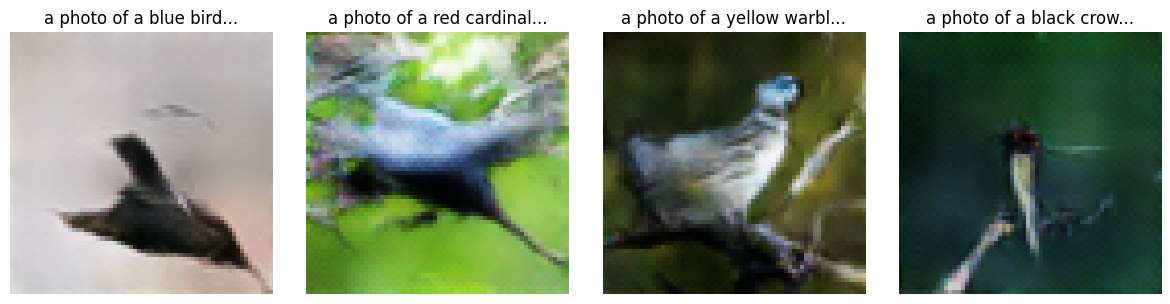

Epoch 200: G=2.4945 D=0.7287


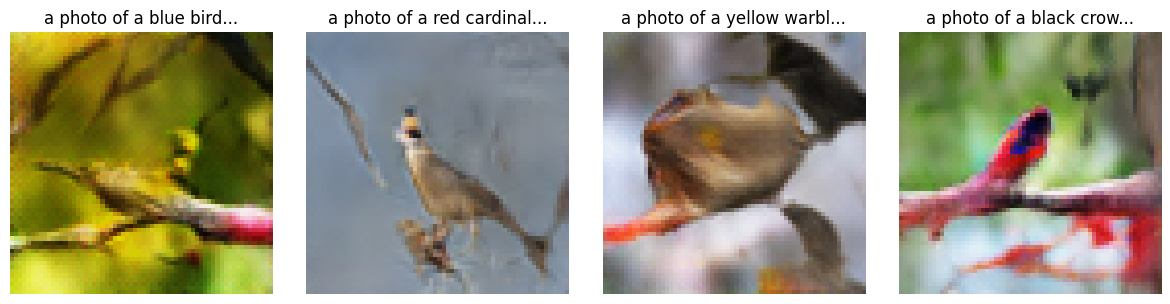

Epoch 250: G=2.4764 D=0.7201


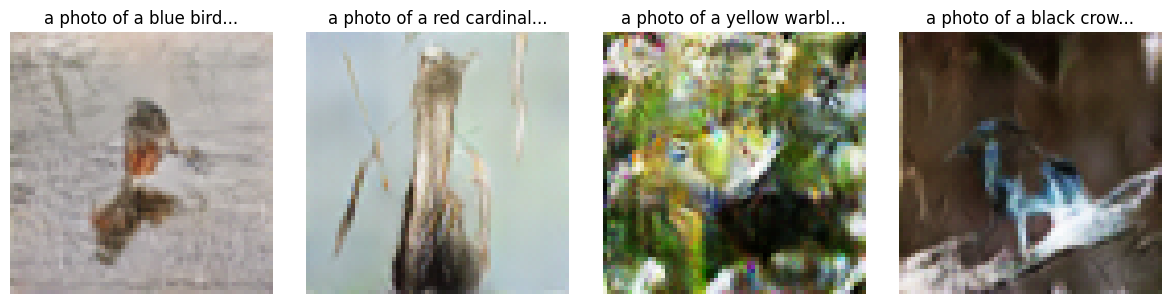

Epoch 300: G=2.4681 D=0.7096


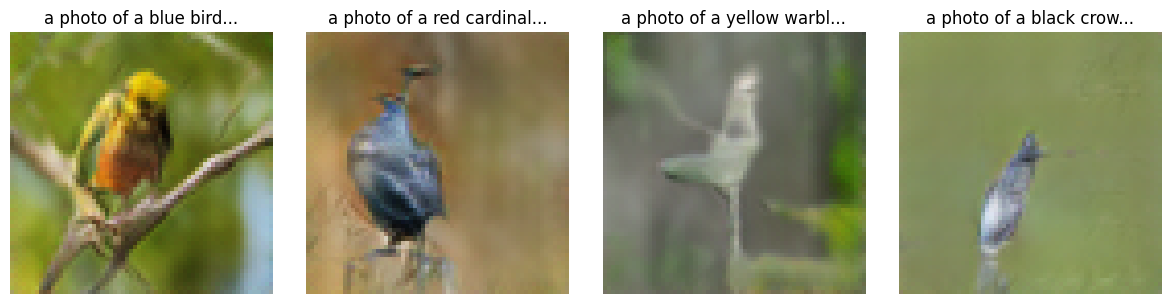

In [12]:
print("Training GAN-CLS...")
gan_cls_g = (
    GAN_CLS_G(cfg.noise_dim, cfg.text_dim, cfg.ngf).to(device).apply(weights_init)
)
gan_cls_d = GAN_CLS_D(cfg.text_dim, cfg.ndf).to(device).apply(weights_init)
g_opt = optim.Adam(gan_cls_g.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
d_opt = optim.Adam(gan_cls_d.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
for e in range(cfg.epochs):
    g, d = train_epoch(gan_cls_g, gan_cls_d, dataloader, g_opt, d_opt)
    if (e + 1) % 50 == 0:
        print(f"Epoch {e+1}: G={g:.4f} D={d:.4f}")
        visualize(gan_cls_g, test_caps)

Training StackGAN-v2...


Epoch 50: G=2.2142 D=0.8166


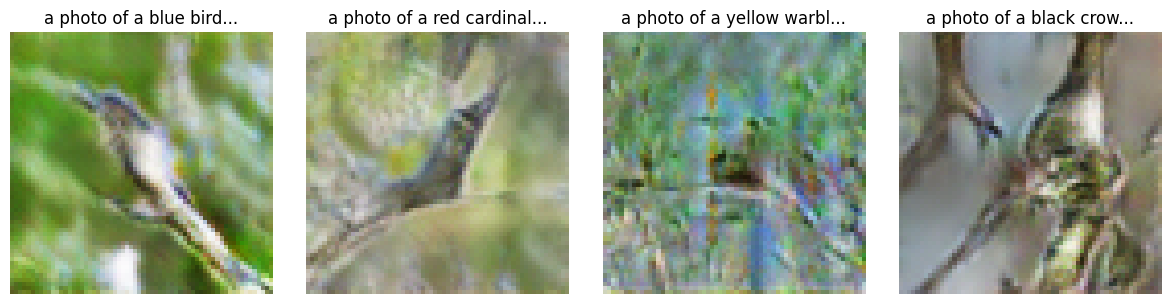

Epoch 100: G=2.2898 D=0.7840


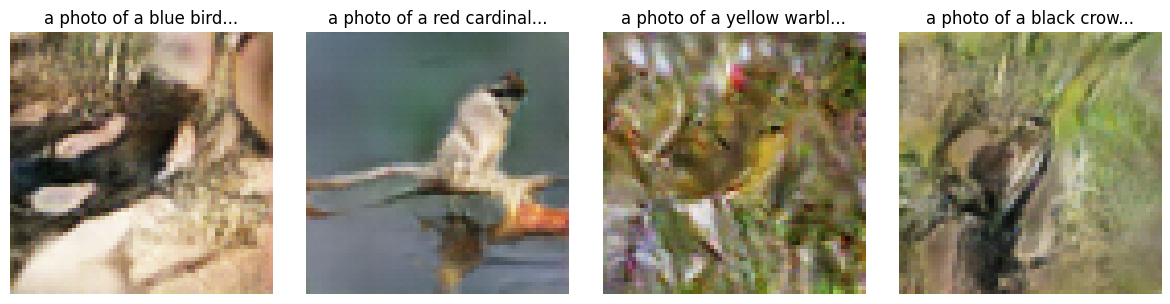

Epoch 150: G=2.3163 D=0.7605


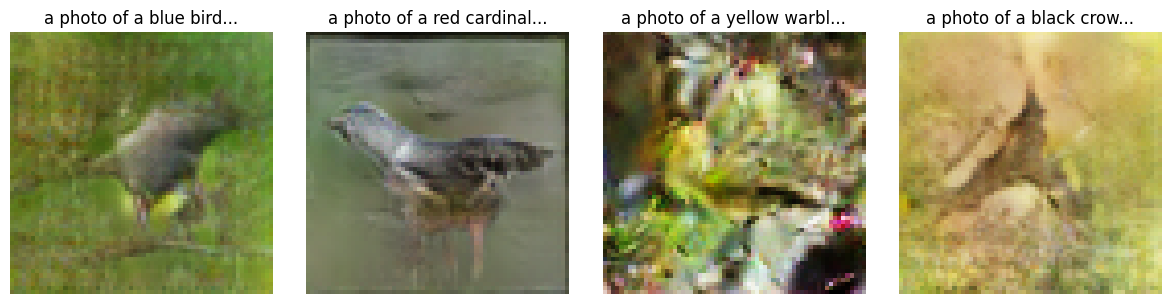

Epoch 200: G=2.3320 D=0.7502


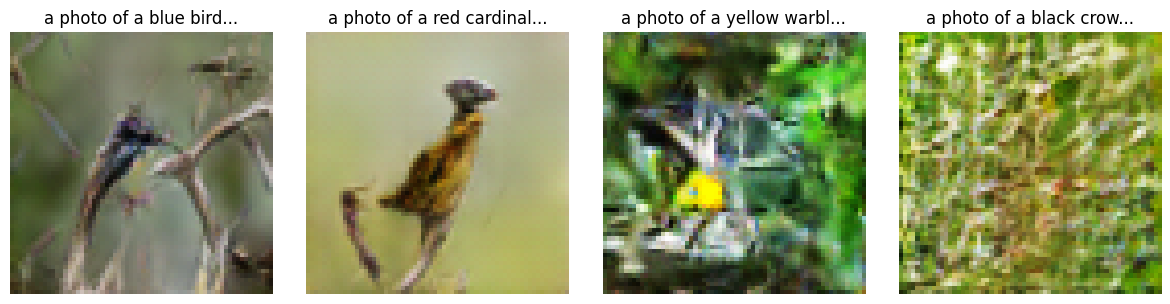

Epoch 250: G=2.3900 D=0.7318


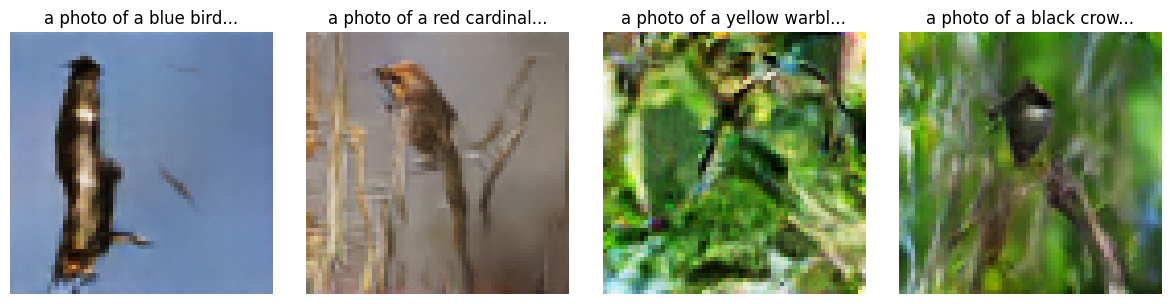

Epoch 300: G=2.4124 D=0.7252


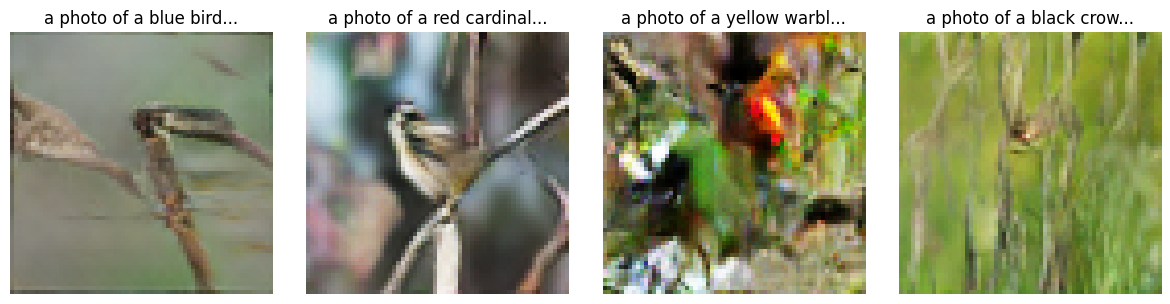

In [11]:
print("Training StackGAN-v2...")
stack_g = (
    StackGAN_G(cfg.noise_dim, cfg.text_dim, cfg.ca_dim, cfg.ngf)
    .to(device)
    .apply(weights_init)
)
stack_d = StackGAN_D(cfg.text_dim, cfg.ndf).to(device).apply(weights_init)
g_opt = optim.Adam(stack_g.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
d_opt = optim.Adam(stack_d.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
for e in range(cfg.epochs):
    g, d = train_epoch(stack_g, stack_d, dataloader, g_opt, d_opt, use_ca=True)
    if (e + 1) % 50 == 0:
        print(f"Epoch {e+1}: G={g:.4f} D={d:.4f}")
        visualize(stack_g, test_caps)

Training AttnGAN...


Epoch 50: G=2.2517 D=0.8118


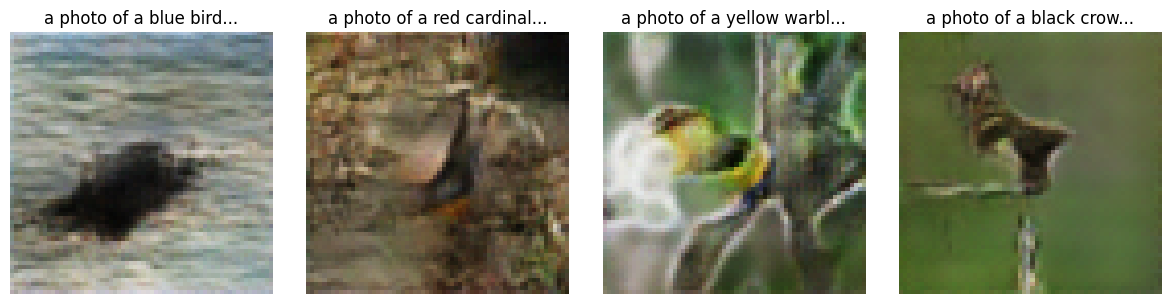

 42%|████▏     | 156/368 [00:17<00:21,  9.78it/s]

In [ ]:
print("Training AttnGAN...")
attn_g = (
    AttnGAN_G(cfg.noise_dim, cfg.text_dim, cfg.ca_dim, cfg.ngf)
    .to(device)
    .apply(weights_init)
)
attn_d = AttnGAN_D(cfg.text_dim, cfg.ndf).to(device).apply(weights_init)
g_opt = optim.Adam(attn_g.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
d_opt = optim.Adam(attn_d.parameters(), lr=cfg.lr, betas=(0.5, 0.999))
for e in range(cfg.epochs):
    g, d = train_epoch(attn_g, attn_d, dataloader, g_opt, d_opt, use_ca=True)
    if (e + 1) % 50 == 0:
        print(f"Epoch {e+1}: G={g:.4f} D={d:.4f}")
        visualize(attn_g, test_caps)

## 5. Evaluation


In [ ]:
from torchvision.models import inception_v3

inception = inception_v3(pretrained=True, transform_input=False).to(device)
inception.fc = nn.Identity()
inception.eval()


def calc_fid(real, fake):
    def feats(x):
        return (
            inception(nn.functional.interpolate(x, (299, 299), mode="bilinear"))
            .detach()
            .cpu()
            .numpy()
        )

    with torch.no_grad():
        r, f = feats(real), feats(fake)
    m1, s1, m2, s2 = (
        r.mean(0),
        np.cov(r, rowvar=False),
        f.mean(0),
        np.cov(f, rowvar=False),
    )
    cov = linalg.sqrtm(s1 @ s2)
    cov = cov.real if np.iscomplexobj(cov) else cov
    return (m1 - m2) @ (m1 - m2) + np.trace(s1 + s2 - 2 * cov)


def gen_imgs(G, n=100):
    G.eval()
    imgs = []
    with torch.no_grad():
        for i in range(0, n, cfg.batch_size):
            caps = [
                dataset.captions[j % len(dataset)]
                for j in range(i, min(i + cfg.batch_size, n))
            ]
            out = G(
                torch.randn(len(caps), cfg.noise_dim, device=device), get_text_emb(caps)
            )
            imgs.append(((out[0] if isinstance(out, tuple) else out) + 1) / 2)
    return torch.cat(imgs)[:n]


real = (torch.stack([dataset[i][0] for i in range(100)]).to(device) + 1) / 2
fid_cls = calc_fid(real, gen_imgs(gan_cls_g).to(device))
fid_stack = calc_fid(real, gen_imgs(stack_g).to(device))
fid_attn = calc_fid(real, gen_imgs(attn_g).to(device))
print(f"FID: GAN-CLS={fid_cls:.1f}, StackGAN={fid_stack:.1f}, AttnGAN={fid_attn:.1f}")

## 6. Comparison


In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(12, 9))
torch.manual_seed(42)
for r, (name, G) in enumerate(
    [("GAN-CLS", gan_cls_g), ("StackGAN-v2", stack_g), ("AttnGAN", attn_g)]
):
    G.eval()
    with torch.no_grad():
        out = G(torch.randn(4, cfg.noise_dim, device=device), get_text_emb(test_caps))
        imgs = ((out[0] if isinstance(out, tuple) else out).cpu() + 1) / 2
    for c in range(4):
        ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).numpy())
        if c == 0:
            ax[r, c].set_ylabel(name, fontsize=12, fontweight="bold")
        if r == 0:
            ax[r, c].set_title(test_caps[c].replace("a photo of a ", ""))
        ax[r, c].axis("off")
plt.suptitle("GAN Comparison (300 epochs)", fontweight="bold")
plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd

print(
    pd.DataFrame(
        {
            "Model": ["GAN-CLS", "StackGAN-v2", "AttnGAN"],
            "FID": [f"{fid_cls:.1f}", f"{fid_stack:.1f}", f"{fid_attn:.1f}"],
            "CA": ["No", "Yes", "Yes"],
            "Attn": ["No", "No", "Yes"],
        }
    ).to_string(index=False)
)

## Conclusion

First we trained on about **1000** about images with **100 epochs**.

**300 epochs** with **full CUB dataset** (~11,788 images) produces significantly better results than 100 epochs.
